# Formate
Für Geodaten existieren eine Vielzahl an Datenformaten, die sich nach ihrer Datenstruktur (Vektor oder Raster) richten.

## Inhaltsverzeichnis
- [Formate für Vektordaten](#Formate-für-Vektordaten)
  - [Simple Feature Access Spezifikation](#Simple-Feature-Access-Spezifikation)
  - [Shapefile](#Shapefile)
  - [GeoJSON](#GeoJSON)
  - [GeoPackage](#GeoPackage)
- [Formate für Rasterdaten](#Formate-für-Rasterdaten)
  - [GeoTIFF](#GeoTIFF)
- [Unterstützung in Datenbanken](#Unterstützung-in-Datenbanken)
  - [PostGIS](#PostGIS)
  - [Andere Datenbanken](#Andere-Datenbanken)

## Formate für Vektordaten
Vektordatenformate speichern Geometrien (Punkte, Linien, Polygone) und deren Attribute.

<br>

<center>
    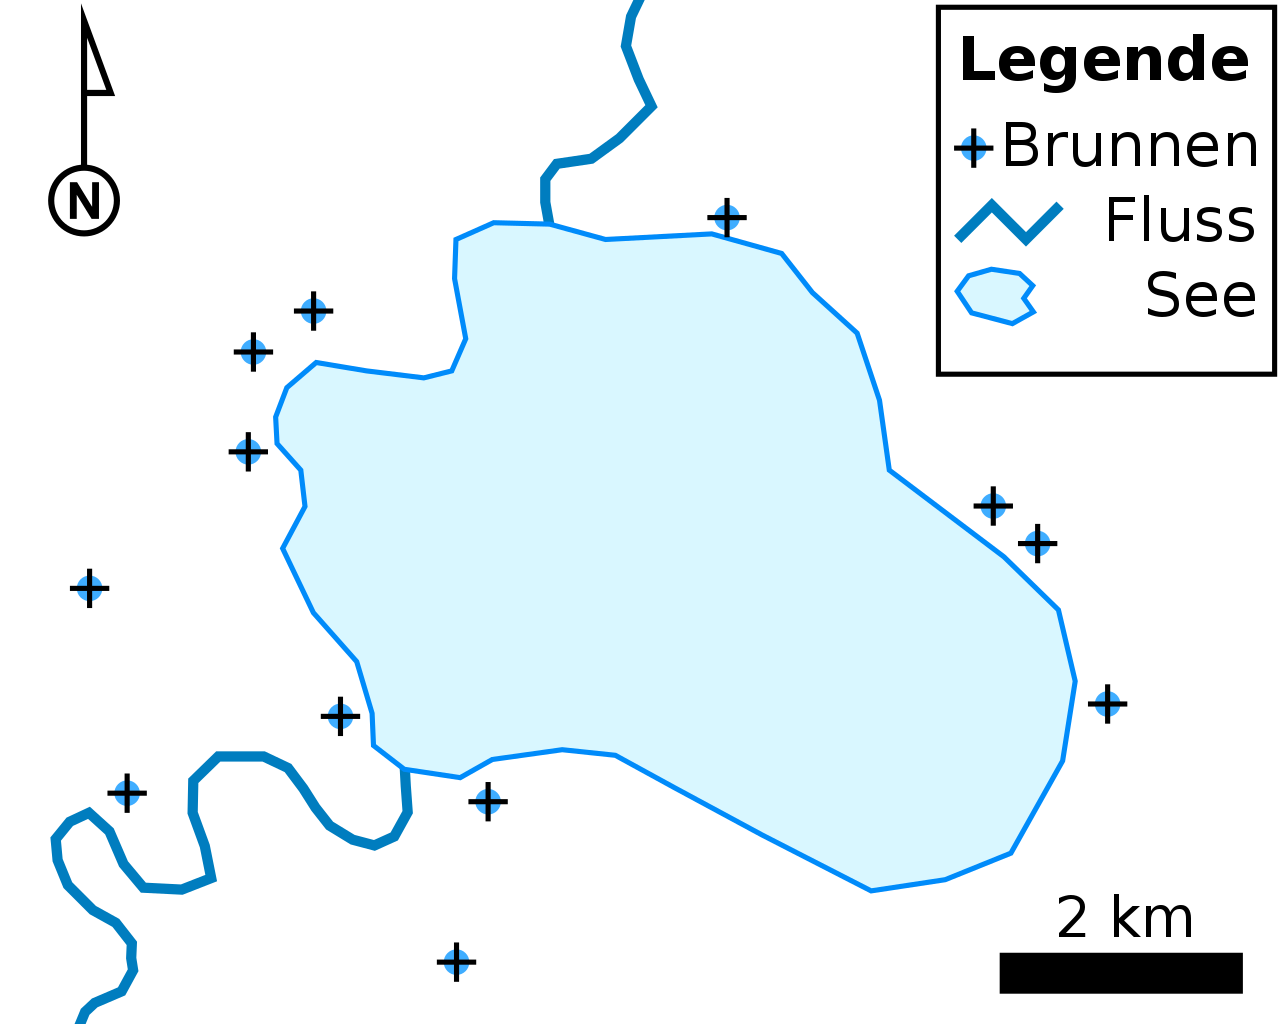 <br>
    <a href="https://commons.wikimedia.org/wiki/File:Eine_einfache_Landkarte_im_Vektorformat.svg">Eine einfache Landkarte im Vektorformat (Mwtoews; CC BY-SA 4.0)</a>
</center>

<br>

Am Beispiel des Sees (Polygon) mit Flüssen (Linien) und Brunnen (Punkte) lassen sich diese Geometrien veranschaulichen.

### Simple Feature Access Spezifikation
Die *Simple Feature Access Spezifikation* des *Open Geospatial Consortium* definiert daher eine Reihe von Klassen zur Repräsentation dieser Geometrien:
- *Point*: Punkte
- *LineString*: Linien
- *Polygon*: Polygone
- *MultiPoint*: Mehrere Punkte
- *MultiLineString*: Mehrere Linien
- *MultiPolygon*: Mehrere Polygone

Zusätzlich existiert die Klasse *GeometryCollection* als Sammlung dieser Geometrien.

Für die Darstellung werden zwei unterschiedliche Repräsentationen vorgeschlagen: **W**ell-**K**nown-**T**ext (WKT) und **W**ell-**K**nown-**B**inary (WKB). Außerdem wird eine Reihe von Methoden definiert, die für die entsprechenden Geometrien verfügbar sein sollten.

### Shapefile
*Shapefile* ist ein weit verbreitetes Format, das immer aus mindestens drei Dateien besteht:
- Die Geometriedatei `.shp` ist eine im Binärformat vorliegende Sammlung von Koordinaten.
- Die Attributdatei `.dbf` ist eine im Binärformat vorliegende Tabelle mit Attributen für jede einzelne Geometrie.
- Die Indexdatei `.shx` ist ein im Binärformat vorliegender Geometrie-Index zum schnelleren Zugriff auf einzelne Geometrien.

### GeoJSON
*GeoJSON* basiert auf JSON und wird häufig für Web-Anwendungen und APIs verwendet. Es ist textbasiert, menschenlesbar und ein JSON-Parser genügt für die Verarbeitung.

Das Format besitzt festgelegte Geometrietypen, die sich an der Simple Feature Access Spezifikation orientieren. Ein einzelner Punkt sieht beispielsweise wie folgt aus:

```json
{
    "type": "Feature",
    "properties": {
        "name": "Zusebau",
        "typ": "Sehenswürdigkeit"
    },
    "geometry": {
        "type": "Point",
        "coordinates": [10.9400, 50.6818]
    }
}
```

Eine *FeatureCollection* kann verwendet werden, um mehrere Objekte zu sammeln.

### GeoPackage
*GeoPackage* ist ein offener Standard des Open Geospatial Consortium, das Daten in einer einzelnen `.gpkg` Datei zusammenfasst. Diese Datei ist eine SQLite-Datenbank, wobei der GeoPackage Standard aber die notwendigen Tabellen, Integritätsbedingungen und inhaltlichen Beschränkungen innerhalb dieser Datenbank vorschreibt. Neben Vektordaten unterstützt GeoPackage auch Rasterdaten.

## Formate für Rasterdaten
Rasterdatenformate speichern Bildpunkte, die aber nicht zwangsweise Aufnahmen von Fotosensoren sein müssen.

<br>

<center>
    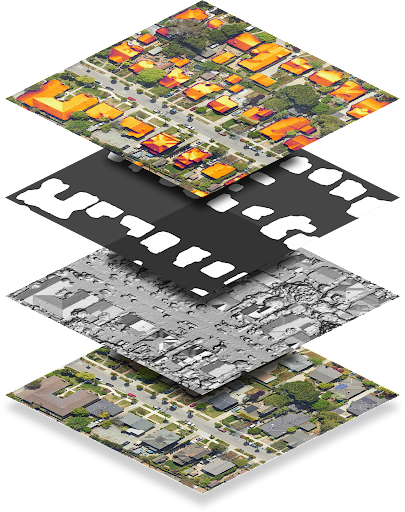 <br>
    <a href="https://developers.google.com/maps/documentation/solar/geotiff">Solar Data Layers (CC-BY 4.0)</a>
</center>

### GeoTIFF
GeoTIFF ist ein offenes Format für Rasterdaten und wird beispielsweise häufig für Satellitenbilder verwendet. Es erlaubt neben verlustfreier Speicherung und Kompression auch die Verwendung mehrerer Ebenen in unterschiedlichen Formaten. So können beispielsweise Aufnahmen von Fotosensoren mit bis zu 32 Bit pro Farbe in einer Datei mit boolschen Werten zur Markierung einer Fläche oder Gleitkommazahlen für Höhenangaben gemeinsam gespeichert werden.

Außerdem unterstützt GeoTIFF Angaben zum räumlichen Bezug der aufgenommenen Grafiken. In Form einer affinen Transformation werden der Startpunkt, die Pixelgröße, Rotation und Verzerrung durch nicht-orthogonale Winkel mitgegeben.

## Unterstützung in Datenbanken
Häufig liegen Geodaten gemeinsam mit anderen Nutzdaten in (relationalen) Datenbanken vor. Einerseits ist dies der Fall, weil keine zweite Datenbanksoftware ausschließlich für räumliche Daten integriert werden soll, und andererseits stellen Datenbanken die bekannten Vorteile wie Integritätsbedingungen und effiziente Abfragen bereit. Daher besteht der Wunsch, dass Geodaten mit diesen (relationalen) Datenbanken nicht nur gespeichert, sondern auch effizient verarbeitet werden können.

### PostGIS
PostGIS ist eine Open-Source-Erweiterung für PostgreSQL und erlaubt das Speichern von Geodaten durch Hinzufügen neuer Datentypen und neuer Funktionen. So kann dann beispielsweise eine neue Tabelle mit einer Spalte `GEOMETRY` angelegt und befüllt werden:

```sql
CREATE TABLE data (name VARCHAR PRIMARY KEY, geom GEOMETRY)
```

```sql
INSERT INTO geometries VALUES
    ('Point', 'POINT(0 0)'),
    ('Linestring', 'LINESTRING(0 0, 1 1, 2 1, 2 2)'),
    ('Polygon', 'POLYGON((0 0, 1 0, 1 1, 0 1, 0 0))')
```

Die elementaren Funktionen der Relationenalgebra lassen sich dann mit auf Geodaten zugeschnittenen Funktionen kombinieren. Das nachfolgende Statement sucht beispielsweise nach allen Gebäuden, die weniger als $50$ Meter von einem Fluss entfernt sind. (`ST_DWithin` gibt `true` zurück, wenn der minimale Abstand zwischen zwei Geometrien kleiner als die angegebene Distanz ist.)

```sql
SELECT Gebaeude.*
FROM Gebaeude
JOIN Fluesse
    ON ST_DWithin(Gebaude.geom, Fluesse.geom, 50)
```

### Andere Datenbanken
Andere relationale Datenbanken können ebenfalls mit GeoDaten arbeiten

**MySQL / MariaDB** unterstützt nativ den Umgang mit einigen räumlichen Datentypen, besitzt aber weniger Funktionen als PostGIS.

**SQLite** benötigt wiederum eine Erweiterung wie [SpatiaLite](https://www.gaia-gis.it/fossil/libspatialite/index). Auch diese kann aber nicht den gleichen Funktionsumfang wie PostGIS vorweisen.